<h1 style="color:red;">GRAPHICAL USER INTERFACE for SVR model to Predict the OVERALL GAS HOLDUP for SLURRY BUBBLE COLUMN REACTORS</h1>

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


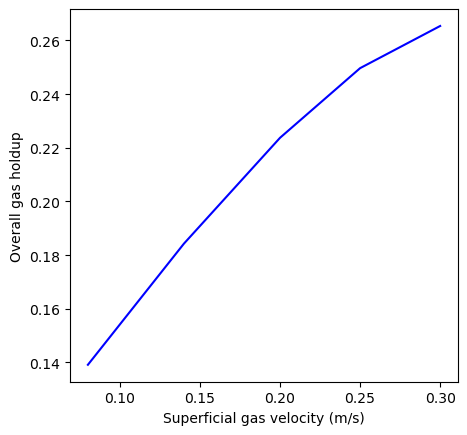

In [3]:
import numpy as np
import pickle
import tensorflow as tf
import tkinter as tk
from tkinter import filedialog, messagebox
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# Load the saved SVR model
with open('svr_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the saved training limits
try:
    with open('training_limits.pkl', 'rb') as f:
        training_limits = pickle.load(f)
except FileNotFoundError:
    messagebox.showerror("Error", "Could not find 'training_limits.pkl'.")
    sys.exit(1)
    
# Initialize the main window
root = tk.Tk()
root.title("SBCR-SVR-GVOF GUI")

# Define a custom style for bold and blue labels
bold_blue_style = {
    "font": ("Helvetica", 12, "bold"),
    "fg": "blue"
}

# Add a label for the GUI statement
statement_label = tk.Label(root, text="Graphical User Interface for Slurry bubble column overall gas holdup using SVR Model", font=("Helvetica", 14, "bold"), fg="green")
statement_label.grid(row=0, column=0, columnspan=3, pady=(10, 5))

# Names for inputs and outputs with subscripts
input_names = ["Temperature (K)", "Pressure (Pascal)", "Superficial gas velocity (m/s)", "Gas molecular weight (kg/kmol)", 
               "Liquid density (kg/m³)", "Liquid viscosity (Pa·s)", "Liquid surface tension (N/m)", "Gas density (kg/m³)", 
               "Column diameter (m)", "Sparger open area (%)", "Particle diameter (m)", "Solid density (kg/m³)", 
               "Solid loading (%)", "Aspect ratio", "PPMN", "PSBC", "RSC"]
output_names = ["Overall gas holdup"]

# Scaling parameters (example means and standard deviations for each input)
input_means = np.array([318.2162802, 520425.0112, 0.138957771, 26.30858311, 899.1571247, 0.005460513, 0.051075938,
                        4.152118799, 0.196756131, 0.826110855, 7.08287E-05, 2652.138828, 11.26763777, 6.729324878, 
                        0.658038147, 0.115803815, 0.226158038])
input_stds = np.array([45.16790293, 1041955.657, 0.120985152, 7.312562995, 118.7449456, 0.009966776, 0.023902353, 9.360067984, 
                       0.084994232, 1.158861456, 3.87255E-05, 532.9706099, 11.15879827, 4.08188804, 0.474366888, 0.319989517, 
                       0.418342659])

# Function to scale inputs
def scale_inputs(inputs):
    return (inputs - input_means) / input_stds

# Function to handle prediction from direct inputs
def predict(inputs):
    try:
        # 1. Convert entry strings from GUI to float values
        input_values = np.array([float(entry.get()) for entry in inputs])

        # 2. Verify the exact number of required inputs
        if len(input_values) != 17:
            raise ValueError("Please enter exactly 17 input values.")

        # 3. Boundary validation check against loaded training limits
        for i, val in enumerate(input_values):
            min_val, max_val = training_limits[i]
            
            if val < min_val or val > max_val:
                name = input_names[i]
                raise ValueError(
                    f"Value for '{name}' ({val:.4f}) is outside the safe training range "
                    f"({min_val:.4f} to {max_val:.4f})."
                )

        # 4. Scale inputs using your scaling function
        scaled_inputs = scale_inputs(input_values)

        # 5. Generate prediction using the reshaped scaled array
        prediction = model.predict(scaled_inputs.reshape(1, -1))

        # 6. Update GUI label with the predicted value
        output_labels[0].config(text=f"{output_names[0]}: {prediction[0][0]:.4f}", fg="red")

        # 7. Clear previous matplotlib plot canvas if it exists in the GUI
        if hasattr(root, 'plot_canvas'):
            root.plot_canvas.get_tk_widget().destroy()

    except ValueError as e:
        # Catches conversion errors, wrong input counts, and out-of-bounds values
        messagebox.showerror("Input Error", str(e))

# Function to handle loading Excel file and prediction
def load_excel_file_and_predict():
    try:
        # Open file dialog to select Excel file
        file_path = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx;*.xls")])
        if file_path:
            # Load data from Excel file
            df = pd.read_excel(file_path)
            
            # Ensure there are exactly 17 inputs
            if df.shape[1] != 17:
                raise ValueError("The loaded Excel file should have exactly 17 input columns.")
            
            # Scale the input values
            scaled_inputs = scale_inputs(df.values)

            # Make predictions for all rows
            predictions = model.predict(scaled_inputs)

            # Clear previous output labels
            for label in output_labels:
                label.config(text="")

            # Display the outputs in red font
            num_predictions = predictions.shape[0]
            for i in range(num_predictions):
                output_text = f"{output_names[0]}: {predictions[i][0]:.4f}"
                
                if i < len(output_labels):
                    output_labels[i].config(text=output_text, fg="red")
                else:
                    new_label = tk.Label(output_frame, text=output_text, fg="red", font=("Helvetica", 12), justify=tk.LEFT)
                    new_label.grid(row=i + 1, column=0, columnspan=2, padx=(10, 10), pady=(5, 0), sticky="w")
                    output_labels.append(new_label)

            # Clear previous plot (if any)
            if hasattr(root, 'plot_canvas'):
                root.plot_canvas.get_tk_widget().destroy()

    except ValueError as e:
        messagebox.showerror("Input Error", str(e))
    except Exception as e:
        messagebox.showerror("Error", f"Failed to load and predict: {str(e)}")

# Function to plot superficial gas velocity vs Overall gas holdup from loaded Excel file
def plot_sgv_vs_ogh():
    try:
        # Open file dialog to select Excel file
        file_path = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx;*.xls")])
        if file_path:
            # Load data from Excel file
            df = pd.read_excel(file_path)
            
            # Ensure there are exactly 17 inputs
            if df.shape[1] != 17:
                raise ValueError("The loaded Excel file should have exactly 17 input columns.")
            
            # Extract superficial gas velocity
            sgv_values = df.iloc[:, 2].values.astype(float)  # Assuming SGV is at index 2 (adjust as per your data)
            
            # Scale the input values
            scaled_inputs = scale_inputs(df.values)

            # Make predictions for all rows
            predictions = model.predict(scaled_inputs)

            # Clear previous plot (if any)
            if hasattr(root, 'plot_canvas'):
                root.plot_canvas.get_tk_widget().destroy()

            # Plot superficial gas velocity vs Overall gas holdup
            fig, ax = plt.subplots(figsize=(5, 4))  # Adjust figsize as needed
            ax.plot(sgv_values, predictions, color='blue')
            ax.set_xlabel('Superficial gas velocity (m/s)')
            ax.set_ylabel('Overall gas holdup')

            # Embed the plot into the Tkinter GUI
            plot_canvas = FigureCanvasTkAgg(fig, master=root)
            plot_canvas.draw()
            plot_canvas.get_tk_widget().grid(row=1, column=2, rowspan=len(input_names), pady=10, padx=(20, 0), sticky="nsew")
            root.plot_canvas = plot_canvas  # Save canvas reference to avoid garbage collection

    except ValueError as e:
        messagebox.showerror("Input Error", str(e))
    except Exception as e:
        messagebox.showerror("Plotting Error", str(e))

# Create a label for inputs section
inputs_label = tk.Label(root, text="INPUTS", **bold_blue_style)
inputs_label.grid(row=1, column=0, columnspan=2, pady=(10, 5))  # Adjust pady as needed

# Create and place input fields for the seventeen inputs
inputs = []
for i, name in enumerate(input_names):
    label = tk.Label(root, text=name + ":", **bold_blue_style)
    label.grid(row=i + 2, column=0, sticky="e", padx=(10, 5))  # Adjust padx as needed
    entry = tk.Entry(root)
    entry.grid(row=i + 2, column=1, padx=(0, 10), pady=5, sticky="w")  # Adjust padx and pady as needed
    inputs.append(entry)

# Create a button to predict from direct inputs
predict_button = tk.Button(root, text="Predict from Inputs", command=lambda: predict(inputs))
predict_button.grid(row=len(input_names) + 2, column=0, columnspan=2, pady=10)

# Create a separator line between inputs and outputs
separator = tk.Frame(root, height=2, bd=1, relief=tk.SUNKEN)
separator.grid(row=len(input_names) + 3, columnspan=2, sticky="ew", pady=10)

# Create a frame for outputs
output_frame = tk.Frame(root)
output_frame.grid(row=len(input_names) + 4, column=0, columnspan=2, padx=(10, 0), sticky="w")

# Create a label for outputs section
outputs_label = tk.Label(output_frame, text="OUTPUTS", **bold_blue_style)
outputs_label.grid(row=0, column=1, columnspan=2, pady=(8, 4), sticky="w")  # Adjust pady as needed

# Create labels to display the output
output_labels = []
for i in range(len(output_names)):
    label = tk.Label(output_frame, text="", fg="red", font=("Helvetica", 12), justify=tk.LEFT)  # Increase font size for outputs
    label.grid(row=i + 1, column=0, columnspan=2, padx=(10, 10), pady=(5, 0), sticky="w")  # Adjust padx and pady as needed
    output_labels.append(label)

# Create a button to load Excel file, predict, and plot
load_excel_button = tk.Button(root, text="Load Excel and Predict", command=load_excel_file_and_predict)
load_excel_button.grid(row=3, column=3, rowspan=len(input_names), padx=20, pady=10, sticky="nsew")  # Shift to the right with padx=20 and sticky="nsew"

# Create a button to plot Superficial gas velocity vs Overall gas holdup
plot_button = tk.Button(root, text="Plot SGV vs OGH", command=plot_sgv_vs_ogh)
plot_button.grid(row=len(input_names) + 2, column=2, padx=20, pady=10, sticky="nsew")

# Start the Tkinter event loop
root.mainloop()